# What is Pandas?
## Pandas is a powerful library used for Data Manipulation and Analysis. It helps us to work with data in Tabular Format.

### Pandas provide functionalities and attributes to clean, organize and analyze large amounts of data.
### Pandas is built on top of NumPy, it introduces two key structures — Series and DataFrame — that make working with tabular and time-series data intuitive and fast.

### Pandas Vs Numpy:
#### NumPy: fast numerical computing on homogeneous arrays (all same dtype).
#### Pandas: labelled, heterogeneous tabular data (columns can have different dtypes) + built-in data cleaning tools.

In [1]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.8 MB 2.3 MB/s eta 0:00:01
     |████████████████████████████████| 347 kB 3.2 MB/s eta 0:00:01
     |████████████████████████████████| 508 kB 4.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd # 'pd' is the universal alias
import numpy as np
print(pd.__version__)

2.3.3


### Two Core Data Structures:
#### 1. Series -> 1D labelled array → A single column of a spreadsheet
#### 2. DataFrame -> 2D labelled table → A full spreadsheet with rows & columns

In [ ]:
# From list (default integer index)
s1 = pd.Series([10, 20, 30, 40, 50])

# From list with custom index
s2 = pd.Series([85, 92, 78], index=['Maths', 'Science', 'English'])

# From dictionary (keys become index)
s3 = pd.Series({'Mumbai': 20.7, 'Delhi': 31.1, 'Bangalore': 17.5})

# From scalar (broadcasts to all index positions)
s4 = pd.Series(5, index=['a', 'b', 'c', 'd'])

# From a NumPy Array with a custom index
data_array = np.array(['a', 'b', 'c', 'd'])
s_array = pd.Series(data_array, index=['w', 'x', 'y', 'z'])

print(s1)
print(s2)
print(s2['Maths']) # 85
# print(s2[0]) # 85 (positional also works) # Will be deprecated -> Use iloc[0]
print(s3)
print(s4)
print(s_array)

0    10
1    20
2    30
3    40
4    50
dtype: int64
Maths      85
Science    92
English    78
dtype: int64
85
Mumbai       20.7
Delhi        31.1
Bangalore    17.5
dtype: float64
a    5
b    5
c    5
d    5
dtype: int64
w    a
x    b
y    c
z    d
dtype: object


#### Series Attributes

In [9]:
s = pd.Series([10, 20, 30], index=['a','b','c'], name='scores')
print(s)
print(s.values) # [10 20 30]
print(s.index) # Index(['a', 'b', 'c'], dtype='object')
print(s.name) # scores
print(s.dtype)
print(s.shape)
print(s.size)

a    10
b    20
c    30
Name: scores, dtype: int64
[10 20 30]
Index(['a', 'b', 'c'], dtype='object')
scores
int64
(3,)
3


#### Accessing Elements

In [12]:
s = pd.Series([100, 200, 300, 400], index=['w','x','y','z'])
print(s['x']) # 200 — by label
print(s[1]) # 200 — by position # Use s.iloc[1]
print(s[['w','z']]) # multiple labels
print(s['x':'z']) # slicing by label (inclusive!)
print(s[1:3]) # slicing by position (exclusive end)

200
200
w    100
z    400
dtype: int64
x    200
y    300
z    400
dtype: int64
x    200
y    300
dtype: int64


/var/folders/hr/l8vxksbd5tzd3dcdp50328fw0000gp/T/ipykernel_49313/2332736125.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(s[1]) # 200 — by position # Use s.iloc[1]


#### .to_numpy() or .values --> Converts the result into a clean NumPy array.

In [27]:
print(s[['w','z']].to_numpy())
print(s[['w','z']].values)
print(type(s[['w','z']].values))

[100 400]
[100 400]
<class 'numpy.ndarray'>


#### .tolist() --> Converts the result into a standard Python list.

In [26]:
print(s[['w','z']].to_list())
print(type(s[['w','z']].to_list()))


[100, 400]
<class 'list'>


### Mathematical Functions & Indexing in Series:

#### Arithmetic aligns on index labels automatically. Where labels don't match, the result is NaN (Not a Number).

In [31]:
s1 = pd.Series([1, 2, 3], index=['a','b','c'])
s2 = pd.Series([10, 20, 40], index=['a','b','d'])
print(s1 + s2)

a    11.0
b    22.0
c     NaN
d     NaN
dtype: float64


In [34]:
# fill_value replaces NaN during operation
# fill_value=0 parameter instructs Pandas to replace any missing or /
# NaN (Not a Number) values with 0 before performing the addition.
print(s1.add(s2, fill_value=0))

a    11.0
b    22.0
c     3.0
d    40.0
dtype: float64


#### Common Mathematical Methods

In [35]:
s = pd.Series([4, 7, 2, 9, 1, 5])
print(s.sum())
print(s.cumsum())
print(s.abs())
print(s.describe())

28
0     4
1    11
2    13
3    22
4    23
5    28
dtype: int64
0    4
1    7
2    2
3    9
4    1
5    5
dtype: int64
count    6.000000
mean     4.666667
std      3.011091
min      1.000000
25%      2.500000
50%      4.500000
75%      6.500000
max      9.000000
dtype: float64


### loc vs iloc
#### loc: Label-based → uses index labels; end is INCLUSIVE
#### iloc: Position-based → uses integer positions; end is EXCLUSIVE

In [36]:
s = pd.Series([10,20,30,40,50], index=['a','b','c','d','e'])
print(s.loc['b':'d']) # b=20, c=30, d=40 (inclusive)
print(s.iloc[1:4]) # pos 1,2,3 → 20, 30, 40 (exclusive end)
print(s.loc[['a','c']]) # 10, 30 — multiple labels
print(s.iloc[[0,2,4]]) # 10, 30, 50 — multiple positions

b    20
c    30
d    40
dtype: int64
b    20
c    30
d    40
dtype: int64
a    10
c    30
dtype: int64
a    10
c    30
e    50
dtype: int64


### Real World Datasets in Series

#### DataFrame: Combination of multiple Series (Columns)
#### squeeze -> squeeze parameter makes sure that the data is in the Series format.

In [52]:
# read_csv() --> Reads content from the csv file in Pandas.
df = pd.read_csv('youtube_single_column2.csv')
df

,Channel Name
0,Smith-Ross Labs
1,Sandoval PLC Hub
2,"Jones, Moore and Ho Network"
3,Mitchell-Hooper Labs
4,Wilson LLC Studios
...,...
4995,Flores-Daniel Studios
4996,Spencer and Sons Studios
4997,Obrien-Roberts Studios
4998,King Ltd Hub


In [56]:
type(df)

pandas.core.frame.DataFrame

In [58]:
# Read a single-column CSV as Series
s = pd.read_csv('youtube_single_column2.csv').squeeze('columns')
s

0                   Smith-Ross Labs
1                  Sandoval PLC Hub
2       Jones, Moore and Ho Network
3              Mitchell-Hooper Labs
4                Wilson LLC Studios
                   ...             
4995          Flores-Daniel Studios
4996       Spencer and Sons Studios
4997         Obrien-Roberts Studios
4998                   King Ltd Hub
4999              Henry Ltd Studios
Name: Channel Name, Length: 5000, dtype: object

In [59]:
type(s)

pandas.core.series.Series

In [60]:
two_cols = pd.read_csv('youtube_two_column.csv')
two_cols

,Youtuber Name,Total Videos
0,Eric Patel,68
1,Cynthia Harrington,128
2,Amanda Walker,282
3,Jessica Nelson MD,302
4,Matthew Sherman,129
...,...,...
4995,Jasmine Smith,106
4996,John Rasmussen,130
4997,Lisa Burke,179
4998,Steve Diaz,182


In [62]:
## index_col --> we can mention what specific column we want as an index column
pd.read_csv('youtube_two_column.csv', index_col='Youtuber Name').squeeze('columns')

Youtuber Name
Eric Patel             68
Cynthia Harrington    128
Amanda Walker         282
Jessica Nelson MD     302
Matthew Sherman       129
                     ... 
Jasmine Smith         106
John Rasmussen        130
Lisa Burke            179
Steve Diaz            182
Austin Tate            92
Name: Total Videos, Length: 5000, dtype: int64

### Handling Missing Data (NaN)
#### Real datasets almost always have missing values. Pandas represents them as NaN (float) or pd.NaT (for dates).

In [14]:
s = pd.Series([10, None, 30, None, 50])
print(s.isnull()) # True where NaN
print(s.notnull()) # True where NOT NaN
print('Total NaN:', s.isnull().sum()) # count of missing values: 2
# Drop NaN
print('Mean:', s.mean())
print(s.dropna())
# Fill NaN with a value
print(s.fillna(0)) # replace with 0
print('Mean after filling with 0:', s.fillna(0).mean())
print(s.fillna(s.mean())) # replace with mean

0    False
1     True
2    False
3     True
4    False
dtype: bool
0     True
1    False
2     True
3    False
4     True
dtype: bool
Total NaN: 2
Mean: 30.0
0    10.0
2    30.0
4    50.0
dtype: float64
0    10.0
1     0.0
2    30.0
3     0.0
4    50.0
dtype: float64
Mean after filling with 0: 18.0
0    10.0
1    30.0
2    30.0
3    30.0
4    50.0
dtype: float64


In [ ]:
print('ffill:', s.ffill()) # forward fill
print('bfill:', s.bfill()) # backward fill

ffill: 0    10.0
1    10.0
2    30.0
3    30.0
4    50.0
dtype: float64
bfill: 0    10.0
1    30.0
2    30.0
3    50.0
4    50.0
dtype: float64


### Exploratory Methods

In [22]:
s = pd.Series(['cat','dog','cat','bird','dog','dog'])
print(s.value_counts())
print(s.unique()) # ['cat' 'dog' 'bird']
print(s.nunique()) # 3
print(s.sort_values())

dog     3
cat     2
bird    1
Name: count, dtype: int64
['cat' 'dog' 'bird']
3
3    bird
0     cat
2     cat
1     dog
4     dog
5     dog
dtype: object


In [25]:
print(s.head(3))
print(s.tail(3))

0    cat
1    dog
2    cat
dtype: object
3    bird
4     dog
5     dog
dtype: object


### DataFrame Introduction
#### A DataFrame is a 2D labelled data structure with rows and columns — like a spreadsheet or SQL table. Each column is a Series, all sharing the same row index.

In [26]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'Age': [25, 30, 35, 28],
    'Score': [88.5, 92.0, 79.5, 95.0],
    'City': ['Mumbai', 'Delhi', 'Pune', 'Chennai']
}
df = pd.DataFrame(data)
print(df)

# From list of dicts
rows = [{'Name':'Alice','Age':25}, {'Name':'Bob','Age':30}]
df2 = pd.DataFrame(rows)
print(df2)

      Name  Age  Score     City
0    Alice   25   88.5   Mumbai
1      Bob   30   92.0    Delhi
2  Charlie   35   79.5     Pune
3    Diana   28   95.0  Chennai
    Name  Age
0  Alice   25
1    Bob   30


In [ ]:
# From NumPy array
import numpy as np
arr = np.random.randint(1,100,(4,3))
df3 = pd.DataFrame(arr, columns=['A','B','C'])
print(df3)

    A   B   C
0  45  33  79
1  94  68  81
2  15  76  77
3  59  25  60


In [37]:
# Create a random generator with a seed (e.g., 42)
rng = np.random.default_rng(seed=42)
# Generate the same integer array using the generator
arr = rng.integers(1, 100, size=(4, 3))
print(arr)
# Generate a 4x3 array of decimals between 0 and 1
print(rng.random((4, 3)))
# Generate a 4x3 array of decimals between 1 and 100 (inclusive of 1, exclusive of 100)
print(rng.uniform(1, 100, (4, 3)))

[[ 9 77 65]
 [44 43 86]
 [ 9 70 20]
 [10 53 97]]
[[0.7611397  0.78606431 0.12811363]
 [0.45038594 0.37079802 0.92676499]
 [0.64386512 0.82276161 0.4434142 ]
 [0.22723872 0.55458479 0.06381726]]
[[82.93548603 63.53477551 76.05068627]
 [36.09807084 97.09910442 89.41899101]
 [78.05996621 20.26923208 47.20537937]
 [ 5.33657281 16.27465971 68.62184637]]


#### Reading from Files

In [38]:
df = pd.read_csv('youtube_2025_dataset_202504061614.csv')
df

,Channel Name,Youtuber Name,Total Videos,Best Video,Avg Video Length (min),Total Subscribers,Members Count,AI Generated Content (%),Neural Interface Compatible,Metaverse Integration Level,Quantum Computing Topics,Holographic Content Rating,Engagement Score,Content Value Index
0,Smith-Ross Labs,Eric Patel,68,VR Challenge: Review 2023,24.8,8264152,303319,9,True,Full,5,3D,130655.44,6.2
1,Sandoval PLC Hub,Cynthia Harrington,128,Nanotech Simulation: Analysis 2024,22.9,8768222,384629,62,False,NaN,4,3D,138624.73,21.4
2,"Jones, Moore and Ho Network",Amanda Walker,282,Metaverse Interface: Analysis 2024,24.0,6163386,361743,31,True,Advanced,6,1D,97442.53,13.5
3,Mitchell-Hooper Labs,Jessica Nelson MD,302,VR Protocol: Review 2023,24.6,4712268,58483,5,False,NaN,15,1D,74500.50,12.0
4,Wilson LLC Studios,Matthew Sherman,129,Nanotech Simulation: Review 2024,24.6,9592017,333873,63,True,NaN,12,3D,151648.85,27.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Flores-Daniel Studios,Jasmine Smith,106,AI Challenge: Experience 2023,22.0,2665835,267828,19,True,Full,1,3D,42146.59,6.4
4996,Spencer and Sons Studios,John Rasmussen,130,VR Challenge: Analysis 2023,26.3,136992,20019,67,True,Full,14,4D,2165.83,29.9
4997,Obrien-Roberts Studios,Lisa Burke,179,AI Challenge: Experience 2023,25.2,2314561,407346,99,True,Advanced,5,1D,36592.98,33.2
4998,King Ltd Hub,Steve Diaz,182,VR Synthesis: Showcase 2023,24.5,6954832,308313,1,True,Basic,9,4D,109955.22,6.6


In [42]:
df.isnull().sum()

Channel Name                      0
Youtuber Name                     0
Total Videos                      0
Best Video                        0
Avg Video Length (min)            0
Total Subscribers                 0
Members Count                     0
AI Generated Content (%)          0
Neural Interface Compatible       0
Metaverse Integration Level    1282
Quantum Computing Topics          0
Holographic Content Rating        0
Engagement Score                  0
Content Value Index               0
dtype: int64

In [57]:
# Common parameters
pd.read_csv('youtube_2025_dataset_202504061614.csv',
sep=',', # delimiter
header=0, # row to use as column names
# index_col='ID', # set a column as index
usecols=['Youtuber Name','Metaverse Integration Level', 'Total Videos'], # read only these columns
nrows=100, # read only first 100 rows
na_values=['NaN', 'NA','?','--'], # treat these as NaN
)

,Youtuber Name,Total Videos,Metaverse Integration Level
0,Eric Patel,68,Full
1,Cynthia Harrington,128,NaN
2,Amanda Walker,282,Advanced
3,Jessica Nelson MD,302,NaN
4,Matthew Sherman,129,NaN
...,...,...,...
95,Philip Ward,138,Basic
96,Ricky Reed,467,Basic
97,Ian Heath,145,Full
98,Frank Harrington,105,Basic


### Series with Python functionalities

#### len -> Total No.of elements present in the Series.
#### type -> Data Type of the Series.
#### dir -> Idea about all of the methods and attributes associated with the Series.
#### sorted -> Sorts the values in ascending manner.

In [71]:
dataframe = df['Youtuber Name']
dataframe

0               Eric Patel
1       Cynthia Harrington
2            Amanda Walker
3        Jessica Nelson MD
4          Matthew Sherman
               ...        
4995         Jasmine Smith
4996        John Rasmussen
4997            Lisa Burke
4998            Steve Diaz
4999           Austin Tate
Name: Youtuber Name, Length: 5000, dtype: object

In [59]:
len(dataframe)

5000

In [60]:
type(dataframe)

pandas.core.series.Series

In [61]:
dir(dataframe)

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__bool__',
 '__class__',
 '__column_consortium_standard__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__or__',
 '__pandas_priority__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__

In [63]:
tot_vids = sorted(df['Total Videos'])
tot_vids

[50,
 50,
 50,
 50,
 50,
 50,
 50,
 50,
 50,
 50,
 50,
 50,
 51,
 51,
 51,
 51,
 51,
 51,
 51,
 51,
 51,
 51,
 51,
 51,
 51,
 51,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 52,
 53,
 53,
 53,
 53,
 53,
 53,
 53,
 53,
 53,
 53,
 53,
 53,
 53,
 54,
 54,
 54,
 54,
 54,
 54,
 54,
 54,
 54,
 54,
 54,
 54,
 54,
 54,
 55,
 55,
 55,
 55,
 55,
 55,
 55,
 55,
 55,
 55,
 56,
 56,
 56,
 56,
 56,
 56,
 56,
 56,
 56,
 56,
 56,
 56,
 56,
 57,
 57,
 57,
 57,
 57,
 57,
 57,
 58,
 58,
 58,
 58,
 58,
 58,
 58,
 58,
 58,
 58,
 59,
 59,
 59,
 59,
 59,
 59,
 59,
 59,
 59,
 59,
 59,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 61,
 61,
 61,
 61,
 61,
 61,
 61,
 61,
 61,
 61,
 61,
 62,
 62,
 62,
 62,
 62,
 62,
 62,
 62,
 62,
 62,
 63,
 63,
 63,
 63,
 63,
 63,
 63,
 63,
 63,
 63,
 63,
 64,
 64,
 64,
 64,
 64,
 64,
 64,
 64,
 64,
 64,
 64,
 64,
 64,
 64,
 64,
 64,
 65,
 65,
 65,
 65,
 65,
 65,
 65,
 65,
 65,
 65,
 65,
 65,
 66,
 66,
 66,
 66,
 66,
 66,
 66,
 66,
 66,
 66,


In [65]:
# Package Function -> object.function()
# Built-in Function -> func(object)
print(max(tot_vids))
print(min(tot_vids))

500
50


#### Type Conversion in Series

* Series to List -> list(Series)
* Series to Dictionary -> dict(Series)

In [67]:
list_vds = list(tot_vids)
print(list_vds)
print(type(list_vds))

[50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 52, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 57, 57, 57, 57, 57, 57, 57, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 66, 66, 66, 66, 66, 66, 66, 66, 66, 66, 66, 66, 66, 66, 66, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 67, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 68, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 70, 70, 70, 70, 70, 70, 70,

In [69]:
dict_df = dict(df)
print(dict_df)
print(type(dict_df))

{'Channel Name': 0                   Smith-Ross Labs
1                  Sandoval PLC Hub
2       Jones, Moore and Ho Network
3              Mitchell-Hooper Labs
4                Wilson LLC Studios
                   ...             
4995          Flores-Daniel Studios
4996       Spencer and Sons Studios
4997         Obrien-Roberts Studios
4998                   King Ltd Hub
4999              Henry Ltd Studios
Name: Channel Name, Length: 5000, dtype: object, 'Youtuber Name': 0               Eric Patel
1       Cynthia Harrington
2            Amanda Walker
3        Jessica Nelson MD
4          Matthew Sherman
               ...        
4995         Jasmine Smith
4996        John Rasmussen
4997            Lisa Burke
4998            Steve Diaz
4999           Austin Tate
Name: Youtuber Name, Length: 5000, dtype: object, 'Total Videos': 0        68
1       128
2       282
3       302
4       129
       ... 
4995    106
4996    130
4997    179
4998    182
4999     92
Name: Total Videos, Length

### Membership Operators

In [79]:
print('Lisa Burke' in df['Youtuber Name']) # Output: False (checks index)
print('Lisa Burke' in df['Youtuber Name'].values) # Output: True (checks actual data)

False
True


In [ ]:
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'City': ['London', 'Paris', 'London', 'New York']
})
print('DF:')
print(df)
# Filter rows based on a list of matching criteria.
mask = df['City'].isin(['Paris', 'New York'])
filtered_df = df[mask]
print(filtered_df)

# Returns True if 'London' is anywhere in the DataFrame
exists = df.isin(['London']).any().any()
print(exists)  # Output: True

# Using in directly on a DataFrame checks if a column name exists.
print('City' in df)      # Output: True
print('Age' in df)       # Output: False

# Using in on df.index checks for a row label.
print(3 in df.index)     # Output: True
print(99 in df.index)    # Output: False


DF:
      Name      City
0    Alice    London
1      Bob     Paris
2  Charlie    London
3    David  New York
    Name      City
1    Bob     Paris
3  David  New York
True
True
False
True
False


In [106]:
print(df[df['City'] == 'Paris'])

# Comparison Operator
print(df[(df['City'] == 'Paris') | (df['City'] == 'London')])

print(df[df['City'].isin(['Paris', 'London'])]) # Recommended


  Name   City
1  Bob  Paris
      Name    City
0    Alice  London
1      Bob   Paris
2  Charlie  London
      Name    City
0    Alice  London
1      Bob   Paris
2  Charlie  London


In [107]:
# We need two .any() calls because a DataFrame is two-dimensional (rows and columns). 
# Each .any() reduces the data by one dimension.
# Calling .any() once reduces the DataFrame into a Series. By default, 
# it checks column by column, asking: "Does this column contain at least one True?"
# Calling .any() the second time reduces the Series into a single scalar value (True/False). 
# It asks: "Does this Series contain at least one True?"
print(df.isin(['London']))
print('---')
print(df.isin(['London']).any())
print('---')
print(df.isin(['London']).any().any())

    Name   City
0  False   True
1  False  False
2  False   True
3  False  False
---
Name    False
City     True
dtype: bool
---
True


### Looping in Series
#### Iterator over Series_name.index

In [113]:
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print('s:')
print(s)

# Looping over Values only
for value in s:
    print(value)

# Looping over both Index and Value
for index, value in s.items():
    print(f"Index: {index}, Value: {value}")

# Looping over Indexes only
# If you only need the row labels, loop over the .index attribute.
for index in s.index:
    print(index)

# The Better Alternative: Avoid Loops using .apply()
# Doubling numbers using a loop (Slow)
for index, value in s.items():
    s[index] = value * 2
print(s)

# Doubling numbers using .apply() (Fast & Clean)
s = s.apply(lambda x: x * 2)
print(s)

import math
print(s.apply(math.sqrt))

s:
a    10
b    20
c    30
dtype: int64
10
20
30
Index: a, Value: 10
Index: b, Value: 20
Index: c, Value: 30
a
b
c
a    20
b    40
c    60
dtype: int64
a     40
b     80
c    120
dtype: int64
a     6.324555
b     8.944272
c    10.954451
dtype: float64


In [114]:
# map() — map values to new values
grades = pd.Series(['A','B','A','C','B'])
grade_map = {'A': 4.0, 'B': 3.0, 'C': 2.0}
print(grades.map(grade_map)) # [4.0, 3.0, 4.0, 2.0, 3.0]

0    4.0
1    3.0
2    4.0
3    2.0
4    3.0
dtype: float64


In [115]:
# String operations via .str accessor
names = pd.Series(['alice', 'bob', 'charlie'])
print(names.str.upper()) # ['ALICE','BOB','CHARLIE']
print(names.str.len()) # [5, 3, 7]
print(names.str.contains('a')) # [True, False, True]
print(names.str.replace('a','@')) # ['@lice', 'bob', 'ch@rlie']

0      ALICE
1        BOB
2    CHARLIE
dtype: object
0    5
1    3
2    7
dtype: int64
0     True
1    False
2     True
dtype: bool
0      @lice
1        bob
2    ch@rlie
dtype: object


### Plotting with Pandas

#### Pandas wraps Matplotlib to allow quick plots directly from Series and DataFrames. Always import matplotlib.pyplot to display plots.

In [117]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 1.9 MB/s eta 0:00:01
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
  Using cached fonttools-4.60.2-cp39-cp39-macosx_10_9_universal2.whl (2.9 MB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


<Axes: >

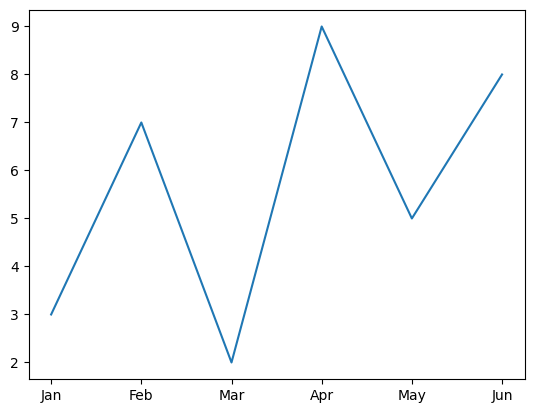

In [118]:
import matplotlib.pyplot as plt
s = pd.Series([3, 7, 2, 9, 5, 8], index=['Jan','Feb','Mar','Apr','May','Jun'])
s.plot()

In [122]:
s.sort_values(ascending=True)

Mar    2
Jan    3
May    5
Feb    7
Jun    8
Apr    9
dtype: int64

In [125]:
s.sort_index(ascending=True)

Apr    9
Feb    7
Jan    3
Jun    8
Mar    2
May    5
dtype: int64

# Various kind values:
* 'line' -> Trends over time / ordered categories
* 'barh' -> Horizontal bar — long category names
* 'hist' -> Distribution of numerical data
* 'box' -> Spread, median, outliers
* 'pie' -> Proportions (use sparingly)
* 'scatter' -> Relationship between two variables (DataFrame)

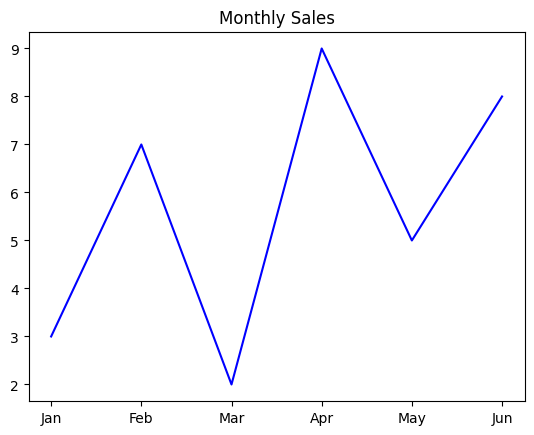

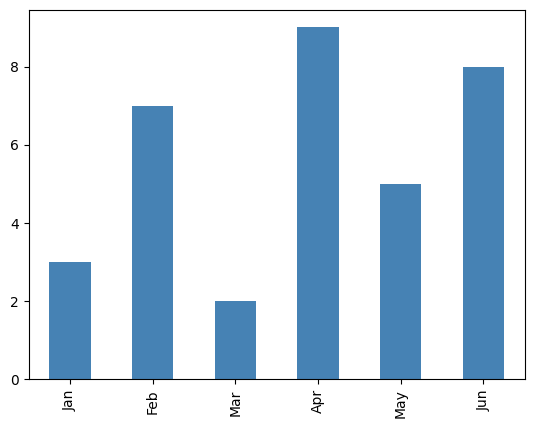

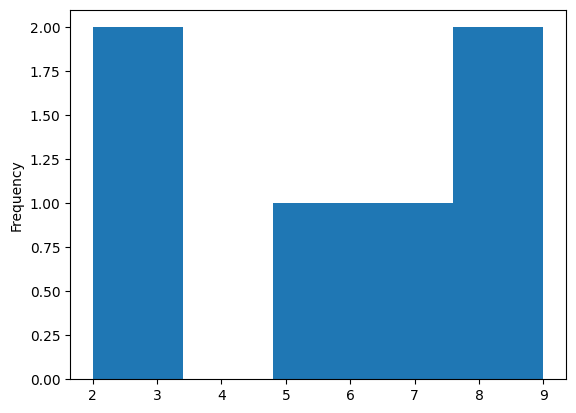

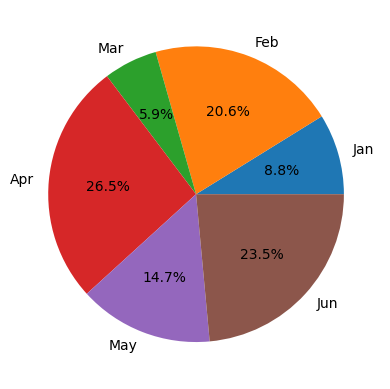

In [127]:
# kind -> Decides what kind of graph you want to plot.
s.plot(kind='line', title='Monthly Sales', color='blue')
plt.show()
s.plot(kind='bar', color='steelblue')
plt.show()
s.plot(kind='hist', bins=5)
plt.show()
s.plot(kind='pie', autopct='%1.1f%%') 
plt.show()
# autopct = '%1.1f%%': 1 decimal place with a % sign
# autopct='%1.2f%%': 2 decimal places with a % sign
# autopct='%d%%': Rounded integer with a % sign

## Creating DataFrames, Attributes & Functions

### Different ways to create Data Frames:
1. Lists
2. Dictionary
3. read_csv()

In [128]:
## dataframe = 2-D Data Structure combination of rows & columns.
rows = [[1,2,3], [4,5,6], [7,8,9], [10,11,12]]
list_data = pd.DataFrame(rows, columns=['a', 'b', 'c'])
list_data

,a,b,c
0,1,2,3
1,4,5,6
2,7,8,9
3,10,11,12


In [129]:
list_data.shape

(4, 3)

In [130]:
list_data.size

12

In [ ]:
print(list_data.ndim) # Always 2 for DataFrame
print(list_data.index) # Row index
print(list_data.columns) # Index of column names

2
RangeIndex(start=0, stop=4, step=1)
Index(['a', 'b', 'c'], dtype='object')


In [136]:
dict_data = {'Name': ['PSPK', 'MSD', 'MB'], 'Money': [5,7,1], 'Financial_Stress': [1,1,0]}
dict_data

{'Name': ['PSPK', 'MSD', 'MB'],
 'Money': [5, 7, 1],
 'Financial_Stress': [1, 1, 0]}

In [137]:
dict_dataframe = pd.DataFrame(dict_data)
dict_dataframe

,Name,Money,Financial_Stress
0,PSPK,5,1
1,MSD,7,1
2,MB,1,0


In [140]:
df = pd.read_csv('student_depression_dataset.csv')
data

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1


In [141]:
type(df)

pandas.core.frame.DataFrame

In [142]:
## Data Exploration -> Attributes & Functions for the DataFrame
df.shape

(27901, 18)

In [ ]:
df.dtypes # Data Type of each column

id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                          object
Family History of Mental Illness          object
Depression                                 int64
dtype: object

In [145]:
# index -> for a DataFrame with labelled index, we can get the idea about the label 
# just by using index attribute
df.index

RangeIndex(start=0, stop=27901, step=1)

In [147]:
df.columns # All Column Names

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [150]:
# values -> idea about values present row by row inside the dataframe. 
# It always returns a 2-D Numpy Array representing the values of column row by row.
df.values

array([[2, 'Male', 33.0, ..., '1.0', 'No', 1],
       [8, 'Female', 24.0, ..., '2.0', 'Yes', 0],
       [26, 'Male', 31.0, ..., '1.0', 'Yes', 0],
       ...,
       [140689, 'Male', 31.0, ..., '2.0', 'No', 0],
       [140690, 'Female', 18.0, ..., '5.0', 'No', 1],
       [140699, 'Male', 27.0, ..., '3.0', 'Yes', 1]], dtype=object)

In [152]:
df.values[0] # 1st row

array([2, 'Male', 33.0, 'Visakhapatnam', 'Student', 5.0, 0.0, 8.97, 2.0,
       0.0, "'5-6 hours'", 'Healthy', 'B.Pharm', 'Yes', 3.0, '1.0', 'No',
       1], dtype=object)

In [154]:
# ndim -> Dimension of the DataFrame.
df.ndim

2

In [156]:
# size -> Total No.of elements present inside the dataframe i.e. all rows * all columns
df.size # 27901*18

502218

### Viewing Data
#### Functions

In [166]:
df.head(5) # first 5 rows (default)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [167]:
df.tail(5) # last 5 rows

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1
27900,140699,Male,27.0,Patna,Student,4.0,0.0,9.24,1.0,0.0,'Less than 5 hours',Healthy,BCA,Yes,2.0,3.0,Yes,1


In [168]:
df.sample(5) # 5 random rows

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
9738,49158,Female,23.0,Vasai-Virar,Student,3.0,0.0,5.08,2.0,0.0,'5-6 hours',Unhealthy,BSc,Yes,12.0,3.0,No,1
18732,94819,Male,24.0,Kolkata,Student,2.0,0.0,7.92,3.0,0.0,'Less than 5 hours',Unhealthy,B.Ed,Yes,4.0,1.0,No,0
11671,58932,Male,33.0,Kalyan,Student,3.0,0.0,7.15,4.0,0.0,'7-8 hours',Unhealthy,BSc,Yes,10.0,4.0,Yes,0
8900,44885,Male,20.0,Nagpur,Student,3.0,0.0,6.10,4.0,0.0,'Less than 5 hours',Unhealthy,'Class 12',Yes,12.0,4.0,No,1
26749,134966,Female,33.0,Kalyan,Student,2.0,0.0,5.76,2.0,0.0,'5-6 hours',Moderate,B.Tech,Yes,12.0,5.0,No,0


In [169]:
df.sample(frac=0.1) # random 10% of rows

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
24890,125371,Male,33.0,Jaipur,Student,4.0,0.0,6.39,1.0,0.0,'Less than 5 hours',Unhealthy,MCA,Yes,12.0,4.0,Yes,1
4368,21894,Male,25.0,Rajkot,Student,3.0,0.0,5.74,4.0,0.0,'Less than 5 hours',Moderate,M.Ed,Yes,10.0,5.0,No,1
20755,105022,Male,33.0,Agra,Student,3.0,0.0,8.58,4.0,0.0,'More than 8 hours',Unhealthy,MD,Yes,8.0,3.0,No,0
25427,128118,Male,25.0,Meerut,Student,5.0,0.0,9.21,3.0,0.0,'7-8 hours',Moderate,PhD,No,8.0,2.0,No,0
15881,80304,Male,26.0,Visakhapatnam,Student,3.0,0.0,7.25,4.0,0.0,'More than 8 hours',Moderate,MCA,Yes,11.0,4.0,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4988,24987,Female,30.0,Chennai,Student,3.0,0.0,7.60,5.0,0.0,'7-8 hours',Moderate,BSc,No,7.0,1.0,No,0
25699,129530,Male,18.0,Thane,Student,2.0,0.0,7.47,4.0,0.0,'More than 8 hours',Unhealthy,'Class 12',No,10.0,5.0,No,1
11100,56173,Female,24.0,Vasai-Virar,Student,3.0,0.0,8.00,3.0,0.0,'Less than 5 hours',Unhealthy,B.Ed,Yes,11.0,5.0,Yes,1
9259,46714,Female,23.0,Kalyan,Student,1.0,0.0,5.32,2.0,0.0,'5-6 hours',Healthy,BSc,No,8.0,2.0,No,0


In [171]:
# info() -> idea about data type of all columns, no.of missing values in each column,
# data type of each column, dataframe storage in memory
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [172]:
# describe() -> mathematical summary of data. Stats for numeric columns: mean, std, min, quartiles, max
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


#### Renaming & Setting Index in DataFrame:

#### .rename() -> Renaming Columns and Index Labels
#### By default, .rename() returns a new DataFrame. To modify your original DataFrame directly without assigning it to a new variable, add inplace=True (e.g., df.rename(columns=..., inplace=True))

In [283]:
df = pd.DataFrame({
    'Emp_ID': [1,2,3],
    'Name': ['Alice', 'Bob', 'Charlie'],
    'City': ['London', 'Paris', 'New York']
})
df

,Emp_ID,Name,City
0,1,Alice,London
1,2,Bob,Paris
2,3,Charlie,New York


In [284]:
# Rename 'Name' to 'Employee Name' and 'City' to 'Location'
df.rename(columns={'Name': 'Employee Name', 'City': 'Location'}, inplace=True)
df

,Emp_ID,Employee Name,Location
0,1,Alice,London
1,2,Bob,Paris
2,3,Charlie,New York


In [285]:
# Setting an Existing Column as the Index 
df_indexed = df.set_index('Emp_ID')
df_indexed

,Employee Name,Location
Emp_ID,,
1,Alice,London
2,Bob,Paris
3,Charlie,New York


#### The <strong>drop=True</strong> Trick
#### Sometimes, your index contains useless numbers or index debris after filtering rows, and you just want to clear it without turning it into a column. Pass drop=True to completely discard the old index:

In [286]:
df_indexed.columns

Index(['Employee Name', 'Location'], dtype='object')

In [287]:
# Reset to 0, 1, 2... and throw away the old index completely
df_clean = df_indexed.reset_index(drop=True)
df_clean
# If Emp_ID is currently your index, drop=True will completely delete it. 
# Only use this if Emp_ID is already safely back in your columns.

,Employee Name,Location
0,Alice,London
1,Bob,Paris
2,Charlie,New York


In [288]:
# Set a column as the row index
df.set_index('Emp_ID', inplace=True)
df

,Employee Name,Location
Emp_ID,,
1,Alice,London
2,Bob,Paris
3,Charlie,New York


In [289]:
# Reset to default integer index
df.reset_index(inplace=True) # Not recommended
df

,Emp_ID,Employee Name,Location
0,1,Alice,London
1,2,Bob,Paris
2,3,Charlie,New York


In [290]:
# For above cell; if run multiple times in notebook; we can see new column gets added like
# index, level_0, level_1, etc.
if df.index.name == 'Emp_ID':
    df.reset_index(inplace=True) # Safer way
df

,Emp_ID,Employee Name,Location
0,1,Alice,London
1,2,Bob,Paris
2,3,Charlie,New York


In [292]:
# Reverting the Index Back to a Column
# If you want to move your index back into a regular column and
# return the row markers to standard numbers (0, 1, 2...), use .reset_index().
# Safe to run 100 times
df_reset = df_indexed.reset_index() # Recommended way
df_reset

,Emp_ID,Employee Name,Location
0,1,Alice,London
1,2,Bob,Paris
2,3,Charlie,New York


In [293]:
df_reset.columns

Index(['Emp_ID', 'Employee Name', 'Location'], dtype='object')

In [294]:
# Rename row index 0 to 'row_1'
df_renamed_rows = df.rename(index={0: 'row_1'})
df_renamed_rows

,Emp_ID,Employee Name,Location
row_1,1,Alice,London
1,2,Bob,Paris
2,3,Charlie,New York


### Handling Missing Values in DataFrame

In [336]:
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Age': [25, np.nan, 30, np.nan, 22],
    'City': ['London', 'Paris', None, 'New York', 'Paris']
})
df

,Name,Age,City
0,Alice,25.0,London
1,Bob,NaN,Paris
2,Charlie,30.0,None
3,David,NaN,New York
4,Eva,22.0,Paris


In [337]:
print(df.isna().sum())

Name    0
Age     2
City    1
dtype: int64


In [338]:
df.isnull().sum() # missing count per column

Name    0
Age     2
City    1
dtype: int64

In [339]:
df.isnull().sum().sum() # total missing values

np.int64(3)

In [340]:
drop_rows = df.dropna() # drop rows with ANY NaN
drop_rows

,Name,Age,City
0,Alice,25.0,London
4,Eva,22.0,Paris


In [341]:
drop_cols = df.dropna(axis=1) # drop columns with ANY NaN
drop_cols

,Name
0,Alice
1,Bob
2,Charlie
3,David
4,Eva


In [342]:
drop_rows_threshold = df.dropna(thresh=3) # keep rows with at least 3 non-NaN
drop_rows_threshold

,Name,Age,City
0,Alice,25.0,London
4,Eva,22.0,Paris


In [343]:
df

,Name,Age,City
0,Alice,25.0,London
1,Bob,NaN,Paris
2,Charlie,30.0,None
3,David,NaN,New York
4,Eva,22.0,Paris


In [344]:
fill_with_zero = df.fillna(0) # fill all NaN with 0
fill_with_zero

,Name,Age,City
0,Alice,25.0,London
1,Bob,0.0,Paris
2,Charlie,30.0,0
3,David,0.0,New York
4,Eva,22.0,Paris


In [345]:
df

,Name,Age,City
0,Alice,25.0,London
1,Bob,NaN,Paris
2,Charlie,30.0,None
3,David,NaN,New York
4,Eva,22.0,Paris


In [346]:
# Or fill specific columns using a dictionary
df_0_unknown = df.fillna({'Age': 0, 'City': 'Unknown'})
df_0_unknown

,Name,Age,City
0,Alice,25.0,London
1,Bob,0.0,Paris
2,Charlie,30.0,Unknown
3,David,0.0,New York
4,Eva,22.0,Paris


In [347]:
df

,Name,Age,City
0,Alice,25.0,London
1,Bob,NaN,Paris
2,Charlie,30.0,None
3,David,NaN,New York
4,Eva,22.0,Paris


In [350]:
# Calculate the average age (ignores NaNs automatically)
mean_age = df['Age'].mean()  # Result is 25.66

# Fill missing ages with the average
df_mean_nan = df['Age'].fillna(mean_age)
df_mean_nan

0    25.000000
1    25.666667
2    30.000000
3    25.666667
4    22.000000
Name: Age, dtype: float64

In [352]:
df

,Name,Age,City
0,Alice,25.0,London
1,Bob,NaN,Paris
2,Charlie,30.0,None
3,David,NaN,New York
4,Eva,22.0,Paris


In [ ]:
# Propagate the last valid age forward
age_ffill = df['Age'].ffill() # upward
age_ffill


0    25.0
1    25.0
2    30.0
3    30.0
4    22.0
Name: Age, dtype: float64

In [ ]:
# Propagate the next valid city backward
city_bfill = df['City'].bfill() # downward
city_bfill

0      London
1       Paris
2    New York
3    New York
4       Paris
Name: City, dtype: object

In [354]:
# If a row is missing too much critical information, you can remove it entirely using .dropna().
# Drop rows only if they have a missing value in the 'Age' column
df_clean = df.dropna(subset=['Age'])
df_clean

,Name,Age,City
0,Alice,25.0,London
2,Charlie,30.0,None
4,Eva,22.0,Paris


##### Advanced Imputation: Fill Missing Age by Group (City)


In [364]:
# Sample DataFrame
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank'],
    'Age': [25, np.nan, 30, np.nan, 22, 40],
    'City': ['London', 'London', 'Paris', 'Paris', 'London', 'Paris']
})

df

,Name,Age,City
0,Alice,25.0,London
1,Bob,NaN,London
2,Charlie,30.0,Paris
3,David,NaN,Paris
4,Eva,22.0,London
5,Frank,40.0,Paris


In [365]:
df.groupby('City')['Age'].transform('mean')

0    23.5
1    23.5
2    35.0
3    35.0
4    23.5
5    35.0
Name: Age, dtype: float64

In [366]:
# Fill missing ages with the mean age of their respective city
df['Age'] = df['Age'].fillna(df.groupby('City')['Age'].transform('mean'))
df # Ex: London: 25+22/2 = 23.5

,Name,Age,City
0,Alice,25.0,London
1,Bob,23.5,London
2,Charlie,30.0,Paris
3,David,35.0,Paris
4,Eva,22.0,London
5,Frank,40.0,Paris


#### Dropping Columns with Too Many Missing Values

In [367]:
# Create a DataFrame where 'Bonus' has too many missing values
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, np.nan, 22],
    'Bonus': [100, np.nan, np.nan, np.nan] # 75% missing data!
})

# Keep only columns that have AT LEAST 2 non-null values
df_cleaned = df.dropna(thresh=2, axis=1)

print(df_cleaned)
# Output: The 'Bonus' column is dropped because it only had 1 non-null value!

      Name   Age
0    Alice  25.0
1      Bob  30.0
2  Charlie   NaN
3    David  22.0


#### If you want to drop columns that are missing, for example, more than 50% of their data, you can set the threshold dynamically using your row count:
#### Require at least 50% of the rows to have data
* min_valid_values = len(df) * 0.5 
* df_cleaned = df.dropna(thresh=min_valid_values, axis=1). This keeps only columns that have AT LEAST 50% valid data


### Important Functions & Fetching Specific Records and Columns